# 02 — Exploratory Data Analysis

**Project**: Detecting Fraudulent Financial Activity Using Behavioral Signals and ML  
**Author**: Zhanerke Zhumash  
**Context**: Independent research, inspired by Mastercard internship hackathon

---

In this notebook we explore the synthetic dataset to understand:
1. Class distribution (fraud vs legitimate)
2. How behavioral signals differ between fraud and legitimate transactions
3. Temporal and geographic patterns in fraud
4. Feature correlations and distributions
5. Which features are most promising for modeling

In [3]:
! pip install pandas
! pip install matplotlib
! pip install seaborn
! pip install scikit-learn 
! pip install matplotlib.pyplot
! pip install numpy
! pip install scipy 


  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
You should consider upgrading via the '/Users/jannerzhumash/Desktop/python_scripts/project/fraud-detection-behavioral-signals/.venv/bin/python3 -m pip install --upgrade pip' command.
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
You should consider upgrading via the '/Users/jannerzhumash/Desktop/pytho

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

%matplotlib inline

## 1. Load Data

In [5]:
# Load datasets
customers = pd.read_csv('../data/raw/customers.csv')
txn = pd.read_csv('../data/raw/transactions.csv')

print(f'Customers: {len(customers):,} rows, {len(customers.columns)} columns')
print(f'Transactions: {len(txn):,} rows, {len(txn.columns)} columns')

Customers: 2,000 rows, 9 columns
Transactions: 50,000 rows, 24 columns


In [6]:
txn.head()

,customer_id,timestamp,amount,merchant_category,channel,device_type,txn_province,home_province,ip_velocity,session_duration_s,...,day_of_week,is_weekend,is_night,province_mismatch,cust_avg_amount,cust_std_amount,amount_zscore,high_velocity_flag,short_session_flag,behavioral_risk_score
0,CUST_000001,2024-01-04 10:01:02.112005,15.63,gas_station,mobile_app,unknown,AB,AB,1,114,...,3,0,0,0,86.620667,56.14036,-1.2645,0,0,0.0
1,CUST_000001,2024-02-03 17:26:08.427261,69.27,electronics,mobile_app,ios,AB,AB,4,270,...,5,1,0,0,86.620667,56.14036,-0.3091,0,0,0.0
2,CUST_000001,2024-02-10 14:58:38.815044,98.78,travel,mobile_app,unknown,SK,AB,2,209,...,5,1,0,1,86.620667,56.14036,0.2166,0,0,0.2
3,CUST_000001,2024-02-16 12:24:55.206758,93.88,grocery,web,ios,AB,AB,3,252,...,4,0,0,0,86.620667,56.14036,0.1293,0,0,0.0
4,CUST_000001,2024-02-25 14:17:02.870091,60.94,entertainment,mobile_app,unknown,AB,AB,1,92,...,6,1,0,0,86.620667,56.14036,-0.4574,0,0,0.0


In [7]:
txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  object 
 1   timestamp              50000 non-null  object 
 2   amount                 50000 non-null  float64
 3   merchant_category      50000 non-null  object 
 4   channel                50000 non-null  object 
 5   device_type            50000 non-null  object 
 6   txn_province           50000 non-null  object 
 7   home_province          50000 non-null  object 
 8   ip_velocity            50000 non-null  int64  
 9   session_duration_s     50000 non-null  int64  
 10  failed_auth_count      50000 non-null  int64  
 11  is_international       50000 non-null  int64  
 12  is_fraud               50000 non-null  int64  
 13  hour_of_day            50000 non-null  int64  
 14  day_of_week            50000 non-null  int64  
 15  is

In [8]:
txn.describe()

,amount,ip_velocity,session_duration_s,failed_auth_count,is_international,is_fraud,hour_of_day,day_of_week,is_weekend,is_night,province_mismatch,cust_avg_amount,cust_std_amount,amount_zscore,high_velocity_flag,short_session_flag,behavioral_risk_score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,117.788283,2.207060,174.456400,0.099660,0.016160,0.035000,13.417800,2.986560,0.282740,0.079760,0.155820,117.788283,197.639705,2.200000e-08,0.020460,0.014640,0.062595
std,412.768258,1.979875,64.519604,0.490278,0.126092,0.183782,4.458116,1.998744,0.450336,0.270924,0.362688,131.271556,347.029268,9.798057e-01,0.141569,0.120108,0.146694
min,0.510000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.754483,2.056410,-2.662800e+00,0.000000,0.000000,0.000000
25%,23.730000,1.000000,134.000000,0.000000,0.000000,0.000000,11.000000,1.000000,0.000000,0.000000,0.000000,39.089655,22.968336,-4.420000e-01,0.000000,0.000000,0.000000
50%,48.360000,2.000000,176.000000,0.000000,0.000000,0.000000,14.000000,3.000000,0.000000,0.000000,0.000000,77.201818,57.562422,-2.203000e-01,0.000000,0.000000,0.000000
75%,99.455000,3.000000,218.000000,0.000000,0.000000,0.000000,16.000000,5.000000,1.000000,0.000000,0.000000,145.352258,237.265071,1.324500e-01,0.000000,0.000000,0.000000
max,19524.040000,29.000000,410.000000,5.000000,1.000000,1.000000,23.000000,6.000000,1.000000,1.000000,1.000000,1325.147368,3916.916435,6.321000e+00,1.000000,1.000000,1.000000


In [9]:
# Check for missing values
print('Missing values per column:')
print(txn.isnull().sum()[txn.isnull().sum() > 0])
if txn.isnull().sum().sum() == 0:
    print('No missing values — dataset is clean.')

Missing values per column:
Series([], dtype: int64)
No missing values — dataset is clean.


## 2. Class Distribution

Fraud detection is a classic **imbalanced classification** problem. Let's see the split.

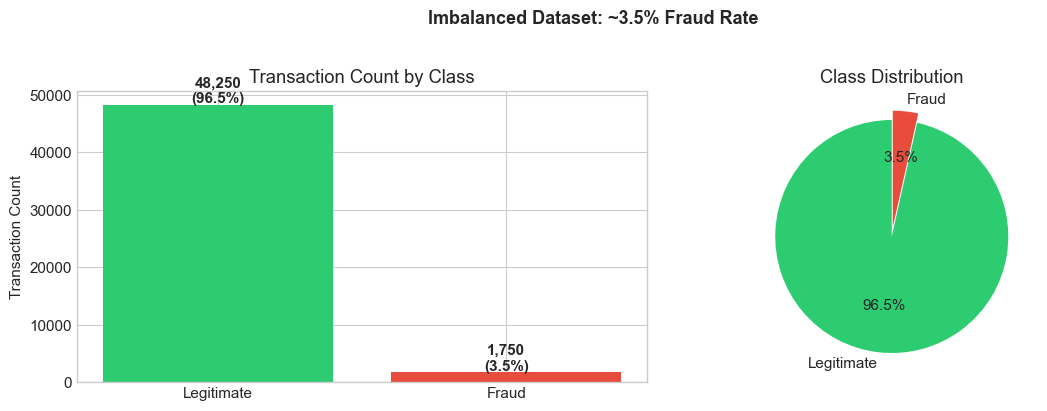

Imbalance ratio: 1 fraud per 27 legitimate transactions


In [17]:
fraud_counts = txn['is_fraud'].value_counts()
fraud_pct = txn['is_fraud'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=colors)
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Transaction Count by Class')
for i, (count, pct) in enumerate(zip(fraud_counts.values, fraud_pct.values)):
    axes[0].text(i, count + 300, f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.08))
axes[1].set_title('Class Distribution')

plt.suptitle('Imbalanced Dataset: ~3.5% Fraud Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Imbalance ratio: 1 fraud per {int(fraud_counts[0] / fraud_counts[1])} legitimate transactions')

## 3. Behavioral Signal Analysis: Fraud vs Legitimate

The core hypothesis of this project is that **behavioral signals** (how people transact) are more revealing than transaction attributes alone. Let's compare.

In [18]:
# Key behavioral features to compare
behavioral_features = [
    'amount', 'ip_velocity', 'failed_auth_count',
    'session_duration_s', 'behavioral_risk_score', 'amount_zscore'
]

# Summary statistics: fraud vs legit
comparison = txn.groupby('is_fraud')[behavioral_features].agg(['mean', 'median', 'std']).round(2)
comparison.index = ['Legitimate', 'Fraud']
comparison

amount                  ip_velocity               \
               mean  median      std        mean median   std   
Legitimate    80.01   47.34   104.68        2.00    2.0  1.00   
Fraud       1159.38  437.90  1855.64        7.92    5.0  7.13   

           failed_auth_count              session_duration_s                \
                        mean median   std               mean median    std   
Legitimate              0.03    0.0  0.17             179.37  179.0  59.53   
Fraud                   2.00    2.0  1.52              39.00   20.0  47.00   

           behavioral_risk_score              amount_zscore               
                            mean median   std          mean median   std  
Legitimate                  0.04    0.0  0.09         -0.08  -0.22  0.76  
Fraud                       0.58    0.7  0.36          2.26   3.15  2.52

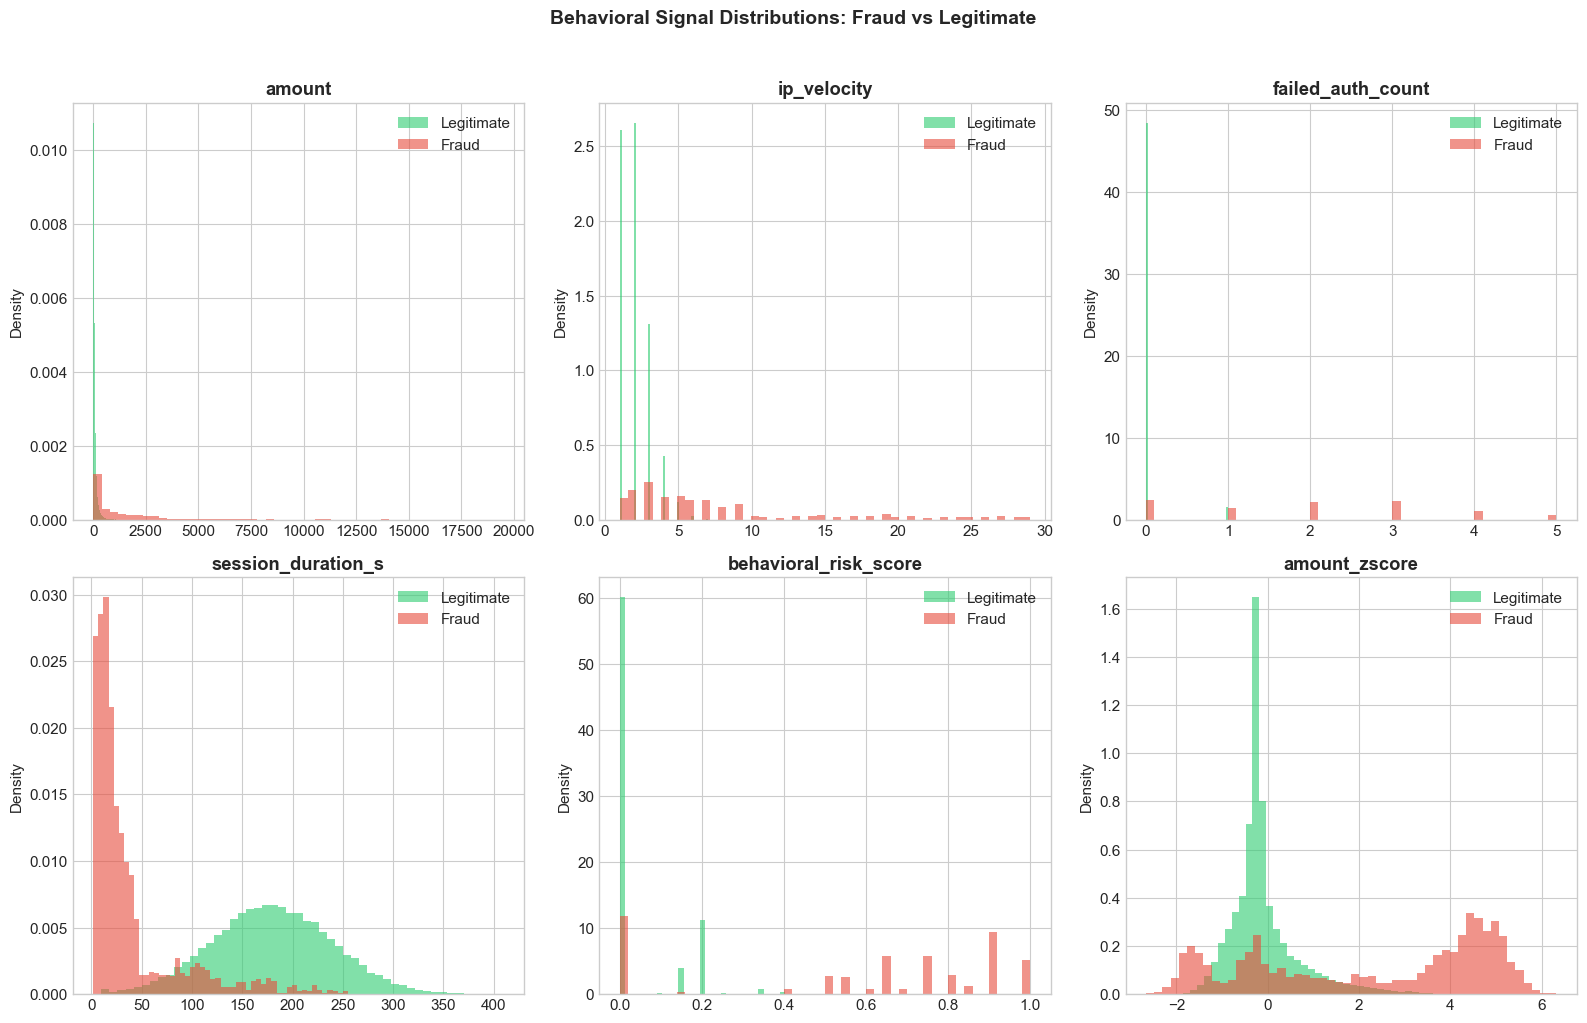

In [19]:
# Distribution plots for each behavioral feature
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(behavioral_features):
    ax = axes[i]
    
    # Separate fraud and legit
    legit_vals = txn[txn['is_fraud'] == 0][feat]
    fraud_vals = txn[txn['is_fraud'] == 1][feat]
    
    ax.hist(legit_vals, bins=50, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
    ax.hist(fraud_vals, bins=50, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Density')

plt.suptitle('Behavioral Signal Distributions: Fraud vs Legitimate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/behavioral_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

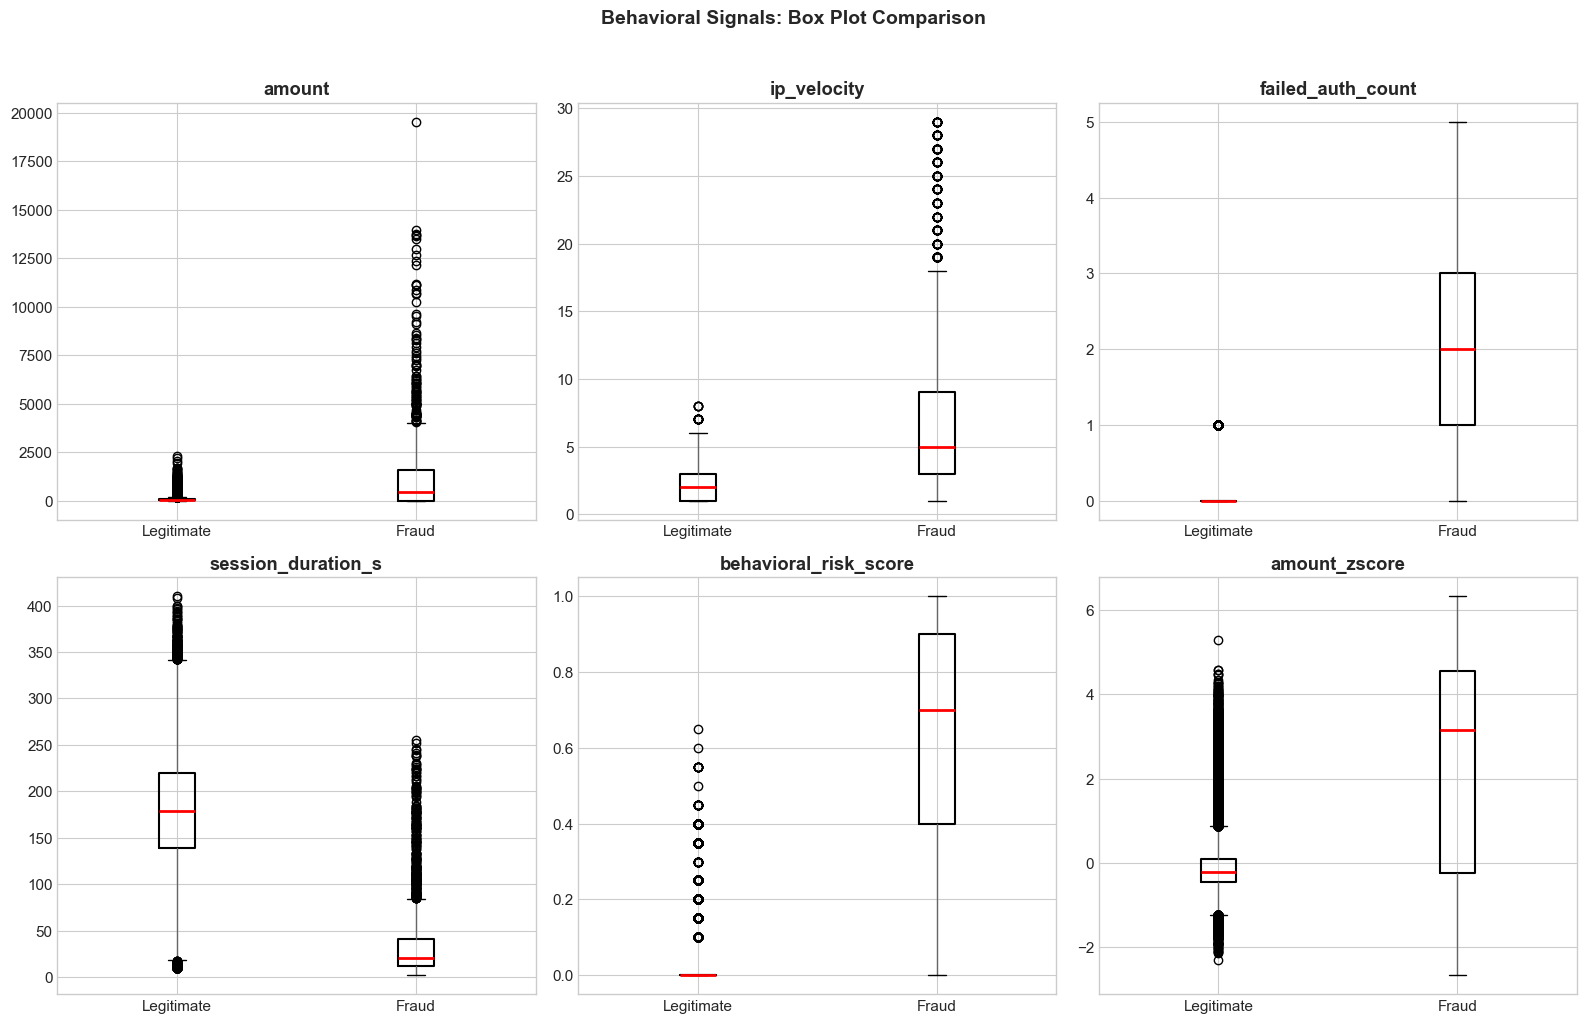

In [20]:
# Box plots for clearer comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(behavioral_features):
    ax = axes[i]
    txn.boxplot(column=feat, by='is_fraud', ax=ax,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Legitimate', 'Fraud'])

plt.suptitle('Behavioral Signals: Box Plot Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/behavioral_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Temporal Patterns

When does fraud happen? Let's look at hourly and daily patterns.

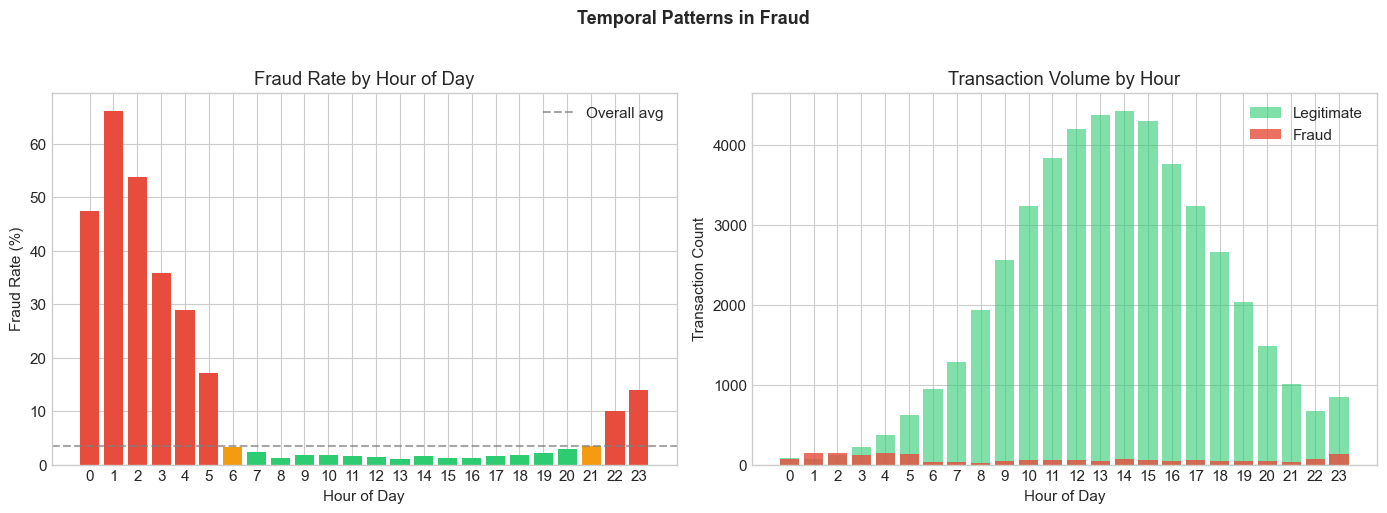

In [21]:
# Fraud rate by hour of day
hourly = txn.groupby('hour_of_day').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).reset_index()
hourly['fraud_rate'] = (hourly['fraud'] / hourly['total'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by hour
colors_hourly = ['#e74c3c' if r > 5 else '#f39c12' if r > 3 else '#2ecc71' for r in hourly['fraud_rate']]
axes[0].bar(hourly['hour_of_day'], hourly['fraud_rate'], color=colors_hourly)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].axhline(y=txn['is_fraud'].mean() * 100, color='gray', linestyle='--', alpha=0.7, label='Overall avg')
axes[0].legend()
axes[0].set_xticks(range(0, 24))

# Transaction volume by hour, split by class
hourly_legit = txn[txn['is_fraud'] == 0]['hour_of_day'].value_counts().sort_index()
hourly_fraud = txn[txn['is_fraud'] == 1]['hour_of_day'].value_counts().sort_index()
axes[1].bar(hourly_legit.index, hourly_legit.values, alpha=0.6, color='#2ecc71', label='Legitimate')
axes[1].bar(hourly_fraud.index, hourly_fraud.values, alpha=0.8, color='#e74c3c', label='Fraud')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Transaction Volume by Hour')
axes[1].legend()
axes[1].set_xticks(range(0, 24))

plt.suptitle('Temporal Patterns in Fraud', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Weekend vs weekday fraud
weekend_fraud = txn.groupby('is_weekend')['is_fraud'].agg(['sum', 'count'])
weekend_fraud['rate'] = (weekend_fraud['sum'] / weekend_fraud['count'] * 100).round(2)
weekend_fraud.index = ['Weekday', 'Weekend']
print('Fraud rate by day type:')
print(weekend_fraud)

# Night vs day fraud
night_fraud = txn.groupby('is_night')['is_fraud'].agg(['sum', 'count'])
night_fraud['rate'] = (night_fraud['sum'] / night_fraud['count'] * 100).round(2)
night_fraud.index = ['Daytime', 'Nighttime (10pm-5am)']
print('\nFraud rate by time of day:')
print(night_fraud)

Fraud rate by day type:
          sum  count  rate
Weekday  1252  35863  3.49
Weekend   498  14137  3.52

Fraud rate by time of day:
                      sum  count   rate
Daytime               772  46012   1.68
Nighttime (10pm-5am)  978   3988  24.52


## 5. Geographic Patterns

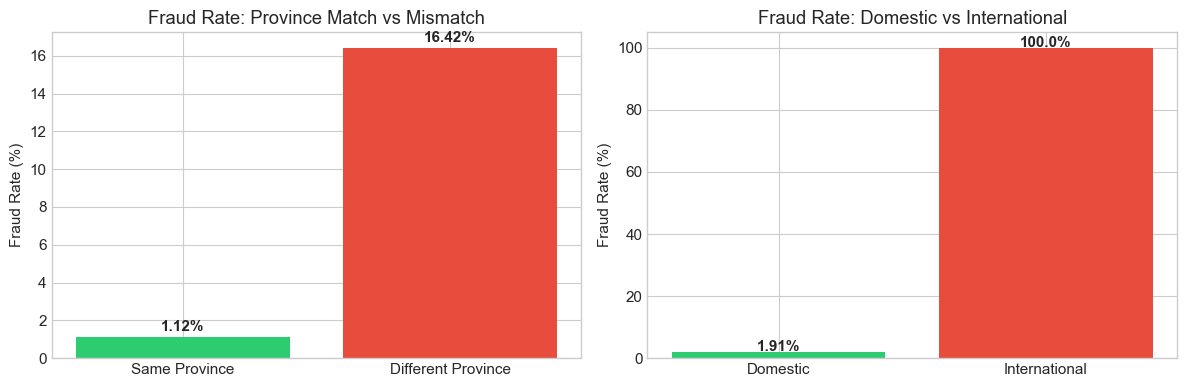

In [23]:
# Province mismatch analysis
mismatch = txn.groupby('province_mismatch')['is_fraud'].agg(['sum', 'count'])
mismatch['rate'] = (mismatch['sum'] / mismatch['count'] * 100).round(2)
mismatch.index = ['Same Province', 'Different Province']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(mismatch.index, mismatch['rate'], color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate: Province Match vs Mismatch')
for i, val in enumerate(mismatch['rate']):
    axes[0].text(i, val + 0.3, f'{val}%', ha='center', fontweight='bold')

# International transactions
intl = txn.groupby('is_international')['is_fraud'].agg(['sum', 'count'])
intl['rate'] = (intl['sum'] / intl['count'] * 100).round(2)
intl.index = ['Domestic', 'International']

axes[1].bar(intl.index, intl['rate'], color=['#2ecc71', '#e74c3c'])
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate: Domestic vs International')
for i, val in enumerate(intl['rate']):
    axes[1].text(i, val + 0.3, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/geographic_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Merchant Category Analysis

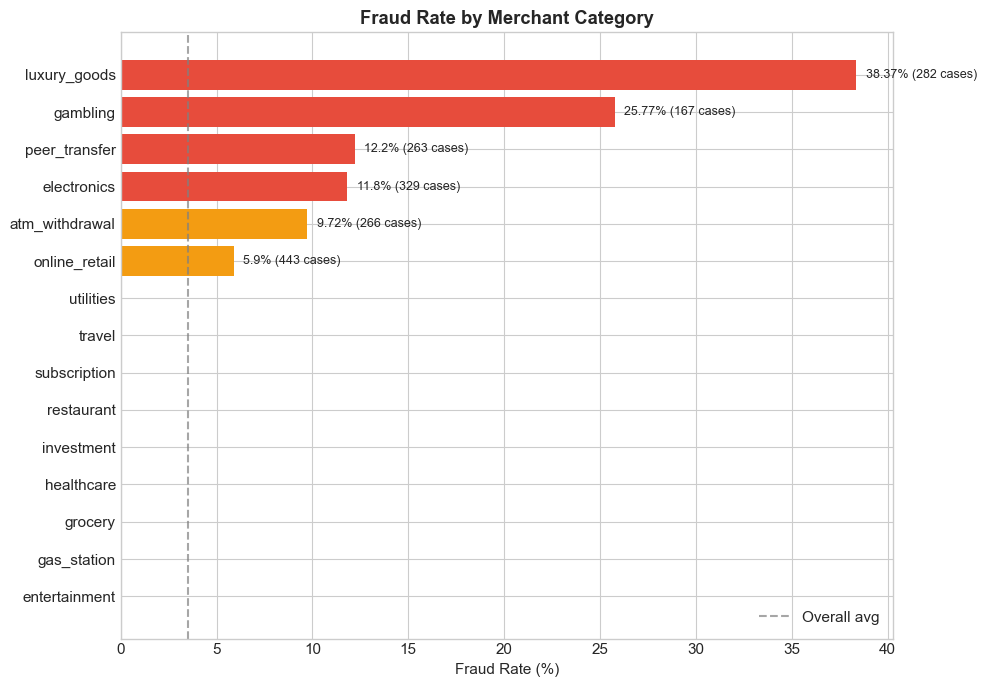

In [24]:
# Fraud rate by merchant category
cat_fraud = txn.groupby('merchant_category')['is_fraud'].agg(['sum', 'count'])
cat_fraud['rate'] = (cat_fraud['sum'] / cat_fraud['count'] * 100).round(2)
cat_fraud = cat_fraud.sort_values('rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_cat = ['#e74c3c' if r > 10 else '#f39c12' if r > 0 else '#2ecc71' for r in cat_fraud['rate']]
ax.barh(cat_fraud.index, cat_fraud['rate'], color=colors_cat)
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Merchant Category', fontweight='bold')
ax.axvline(x=txn['is_fraud'].mean() * 100, color='gray', linestyle='--', alpha=0.7, label='Overall avg')
ax.legend()

for i, (rate, count) in enumerate(zip(cat_fraud['rate'], cat_fraud['sum'])):
    if rate > 0:
        ax.text(rate + 0.5, i, f'{rate}% ({int(count)} cases)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/merchant_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Correlations

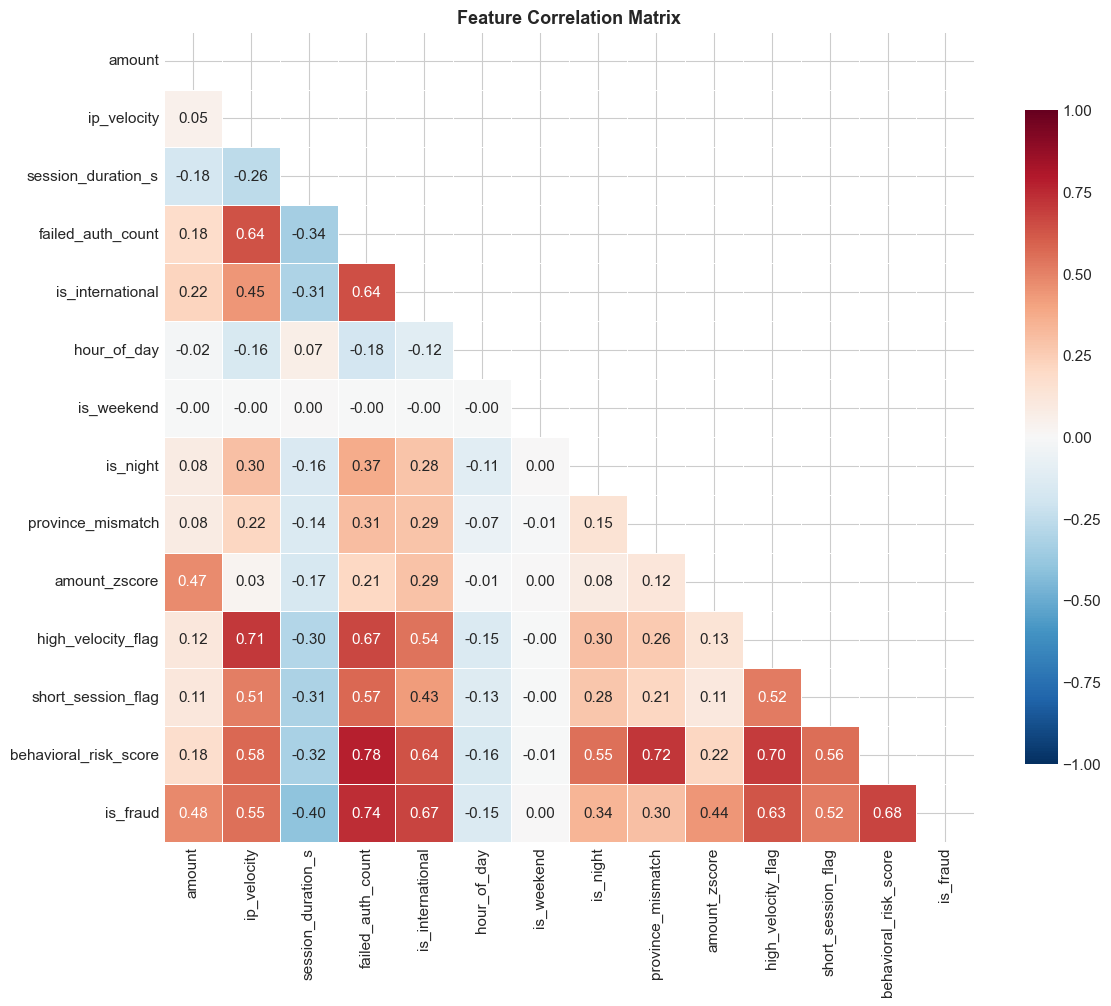

In [25]:
# Correlation heatmap of numeric features with the fraud label
numeric_cols = [
    'amount', 'ip_velocity', 'session_duration_s', 'failed_auth_count',
    'is_international', 'hour_of_day', 'is_weekend', 'is_night',
    'province_mismatch', 'amount_zscore', 'high_velocity_flag',
    'short_session_flag', 'behavioral_risk_score', 'is_fraud'
]

corr_matrix = txn[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

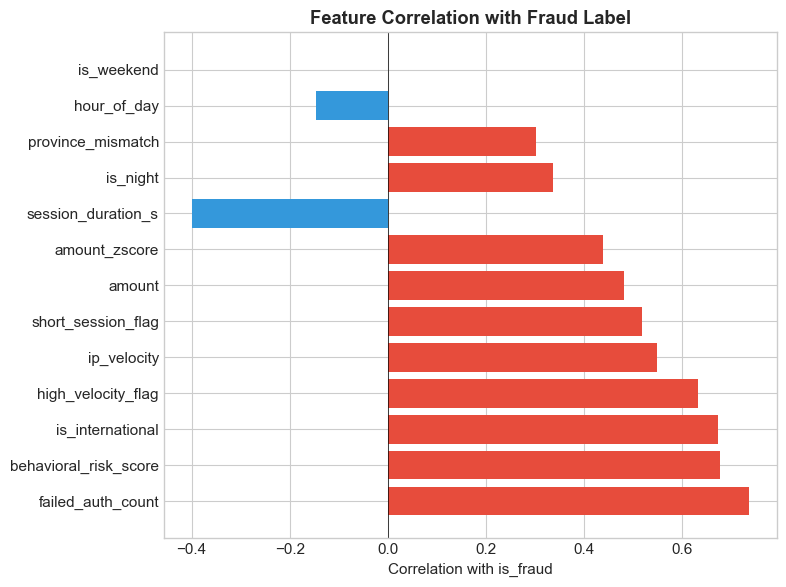

Top 5 features most correlated with fraud:
  failed_auth_count               r = +0.7366
  behavioral_risk_score           r = +0.6779
  is_international                r = +0.6730
  high_velocity_flag              r = +0.6328
  ip_velocity                     r = +0.5494


In [26]:
# Top features correlated with fraud
fraud_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors_corr = ['#e74c3c' if v > 0 else '#3498db' for v in fraud_corr.values]
ax.barh(fraud_corr.index, fraud_corr.values, color=colors_corr)
ax.set_xlabel('Correlation with is_fraud')
ax.set_title('Feature Correlation with Fraud Label', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../outputs/figures/fraud_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features most correlated with fraud:')
for feat, val in fraud_corr.head(5).items():
    print(f'  {feat:30s}  r = {val:+.4f}')

## 8. Channel & Device Analysis

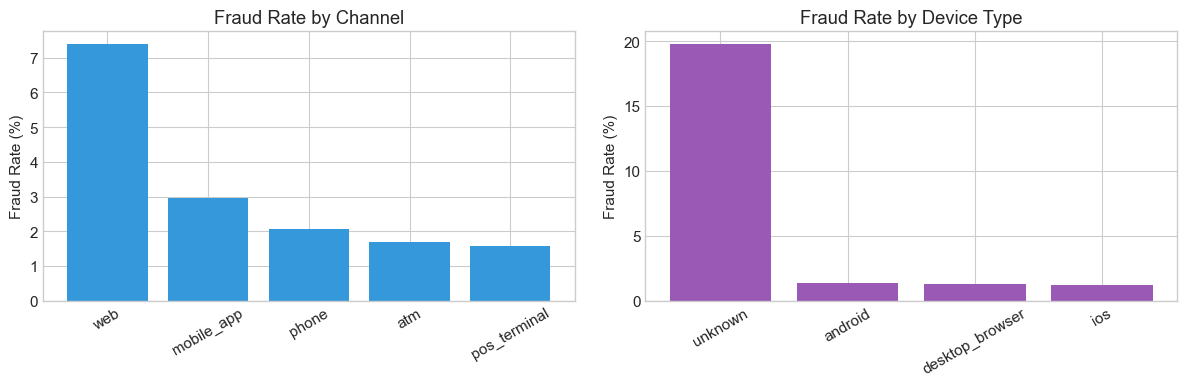

In [27]:
# Fraud by channel
channel_fraud = txn.groupby('channel')['is_fraud'].agg(['sum', 'count'])
channel_fraud['rate'] = (channel_fraud['sum'] / channel_fraud['count'] * 100).round(2)
channel_fraud = channel_fraud.sort_values('rate', ascending=False)

# Fraud by device
device_fraud = txn.groupby('device_type')['is_fraud'].agg(['sum', 'count'])
device_fraud['rate'] = (device_fraud['sum'] / device_fraud['count'] * 100).round(2)
device_fraud = device_fraud.sort_values('rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(channel_fraud.index, channel_fraud['rate'], color='#3498db')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Channel')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(device_fraud.index, device_fraud['rate'], color='#9b59b6')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Device Type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/figures/channel_device_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Behavioral Risk Score Deep Dive

This composite score is the key engineered feature — let's see how well it separates fraud.

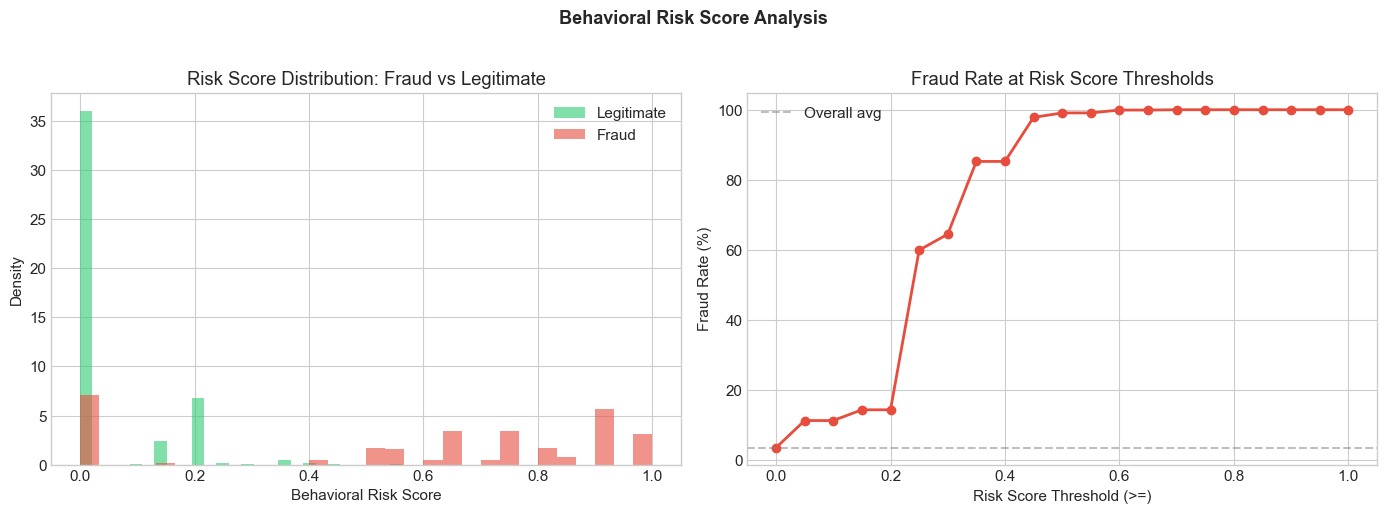

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution overlap
axes[0].hist(txn[txn['is_fraud'] == 0]['behavioral_risk_score'], bins=30, alpha=0.6,
             color='#2ecc71', label='Legitimate', density=True)
axes[0].hist(txn[txn['is_fraud'] == 1]['behavioral_risk_score'], bins=30, alpha=0.6,
             color='#e74c3c', label='Fraud', density=True)
axes[0].set_xlabel('Behavioral Risk Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Risk Score Distribution: Fraud vs Legitimate')
axes[0].legend()

# Fraud rate at each risk score threshold
thresholds = np.arange(0, 1.05, 0.05)
fraud_rates_at_threshold = []
counts_at_threshold = []
for t in thresholds:
    subset = txn[txn['behavioral_risk_score'] >= t]
    if len(subset) > 0:
        fraud_rates_at_threshold.append(subset['is_fraud'].mean() * 100)
        counts_at_threshold.append(len(subset))
    else:
        fraud_rates_at_threshold.append(0)
        counts_at_threshold.append(0)

axes[1].plot(thresholds, fraud_rates_at_threshold, 'o-', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Risk Score Threshold (>=)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate at Risk Score Thresholds')
axes[1].axhline(y=txn['is_fraud'].mean() * 100, color='gray', linestyle='--', alpha=0.5, label='Overall avg')
axes[1].legend()

plt.suptitle('Behavioral Risk Score Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/risk_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Key Findings

**Class imbalance**: ~3.5% fraud rate. We'll need class-balanced training or SMOTE.

**Strongest behavioral signals**:
- `behavioral_risk_score`: composite score shows clear separation
- `failed_auth_count`: fraud transactions have significantly more failed logins
- `ip_velocity`: fraudsters hit from the same IP much faster
- `amount_zscore`: fraud amounts deviate heavily from customer norms
- `session_duration_s`: fraud sessions are extremely short (bot-like)

**Temporal insight**: Fraud concentrates in late-night hours (10pm–5am).

**Geographic insight**: Province mismatch and international transactions are strong fraud indicators.

**Merchant categories**: Luxury goods, gambling, and electronics have the highest fraud rates.